# 01: Long-Term Seasonality (Year-over-Year Patterns)
This notebook analyzes recurring annual trends in Wikipedia traffic from 2015 to 2025.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add src to path
sys.path.append(os.path.abspath('../../'))
from src.data_prep import clean_pageview_data, add_time_features

# Configuration
DATA_PATH = '../../data/raw/en_wiki_pageviews_monthly.csv'
REPORT_DIR = '../../reports/'
os.makedirs(REPORT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="rocket")

## 1. Load and Clean Data

In [2]:
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = clean_pageview_data(df)
df = add_time_features(df)

print(f"Data loaded from {DATA_PATH}")
df.head()

Data loaded from ../../data/raw/en_wiki_pageviews_monthly.csv


,timestamp,views,day_of_week,month,year,is_weekend
0,2015-07-01,7665421980,Wednesday,July,2015,False
1,2015-08-01,7634815221,Saturday,August,2015,True
2,2015-09-01,7655695037,Tuesday,September,2015,False
3,2015-10-01,7746031887,Thursday,October,2015,False
4,2015-11-01,7524321290,Sunday,November,2015,True


## 2. Long-Term Trend (12-Month Moving Average)

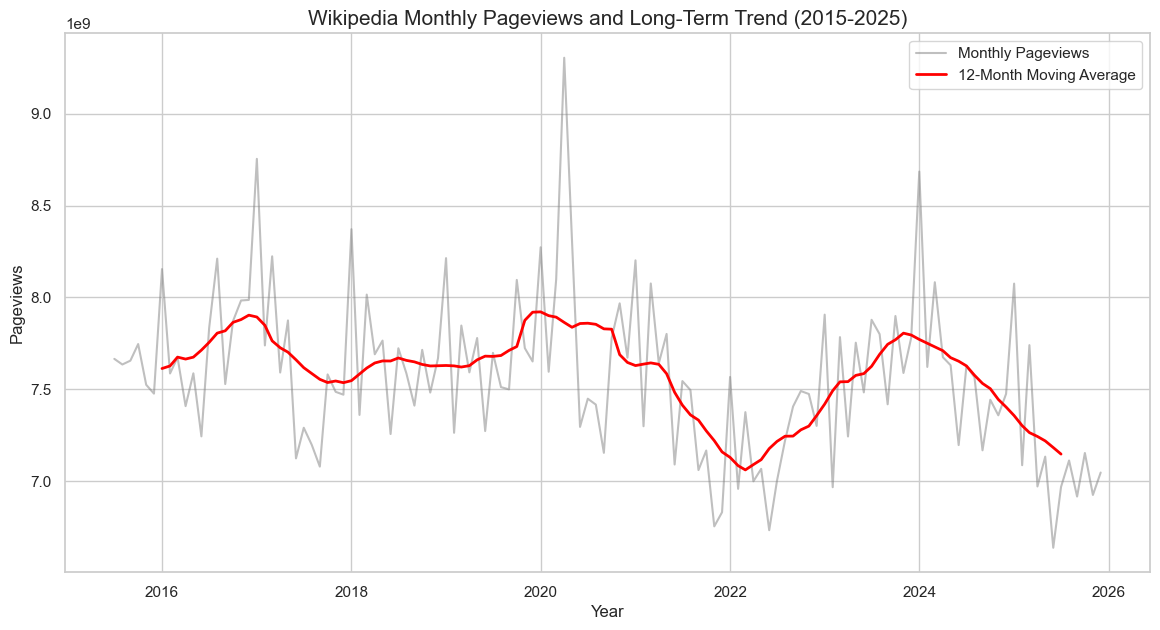

In [3]:
df['moving_avg'] = df['views'].rolling(window=12, center=True).mean()

plt.figure(figsize=(14, 7))
plt.plot(df['timestamp'], df['views'], label='Monthly Pageviews', alpha=0.5, color='gray')
plt.plot(df['timestamp'], df['moving_avg'], label='12-Month Moving Average', color='red', linewidth=2)
plt.title('Wikipedia Monthly Pageviews and Long-Term Trend (2015-2025)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Pageviews', fontsize=12)
plt.legend()
plt.savefig(os.path.join(REPORT_DIR, 'section_1_long_term_trend.png'))
plt.show()

###  Overview
The graph shows Wikipedia’s monthly pageviews from 2015 to 2025 along with a 12-month moving average representing the long-term trend. While the moving average highlights the general direction of traffic, the monthly pageview line displays short-term fluctuations that are often driven by global events, political developments, and major cultural or technological discussions. These spikes indicate how Wikipedia usage increases when users seek reliable background information about ongoing events.

### Key Trends and Influencing Events
#### 2015–2017: Gradual Growth with Political and Global Events

During this period, Wikipedia experienced a gradual rise in pageviews. Several major global developments likely contributed to increased traffic. The 2016 United States presidential election and the Brexit referendum generated widespread international attention.
The spike observed around 2017 may also be linked to the inauguration of the U.S. president and the rapid rise of cryptocurrency interest, particularly Bitcoin.

#### 2018–2019: Stable Engagement with Event-Driven Spikes

Between 2018 and 2019, the overall trend becomes relatively stable, suggesting a mature and consistent user base. However, several global events continued to generate short-term increases in pageviews. For example, the 2018 FIFA World Cup and growing global discussions around climate change activism.

#### 2020: Major Global Spike

The most significant peak occurs in 2020, primarily driven by the COVID-19 pandemic, which forced people to spend more time online. Other major developments such as the 2020 U.S. presidential election and global Black Lives Matter protests also contributed to increased Wikipedia traffic during this period.

#### 2021–2024: Decline, Recovery, and Global Developments

After the 2020 peak, pageviews decline as the lockdown was lisfted on most places. The Russia–Ukraine war beginning in 2022 likely generated increased searches related to geopolitics and international relations.A moderate recovery in traffic around 2023–2024 may also reflect growing global interest in artificial intelligence technologies and other emerging technological developments.

#### 2024–2025: Slight Downward Trend

Toward the end of the dataset, the moving average shows a gradual decline. This may reflect changing digital information consumption patterns, where users increasingly rely on AI assistants, search engine summaries, and short-form content platforms instead of visiting full reference websites directly.

## 3. Year-over-Year Overlay Patterns

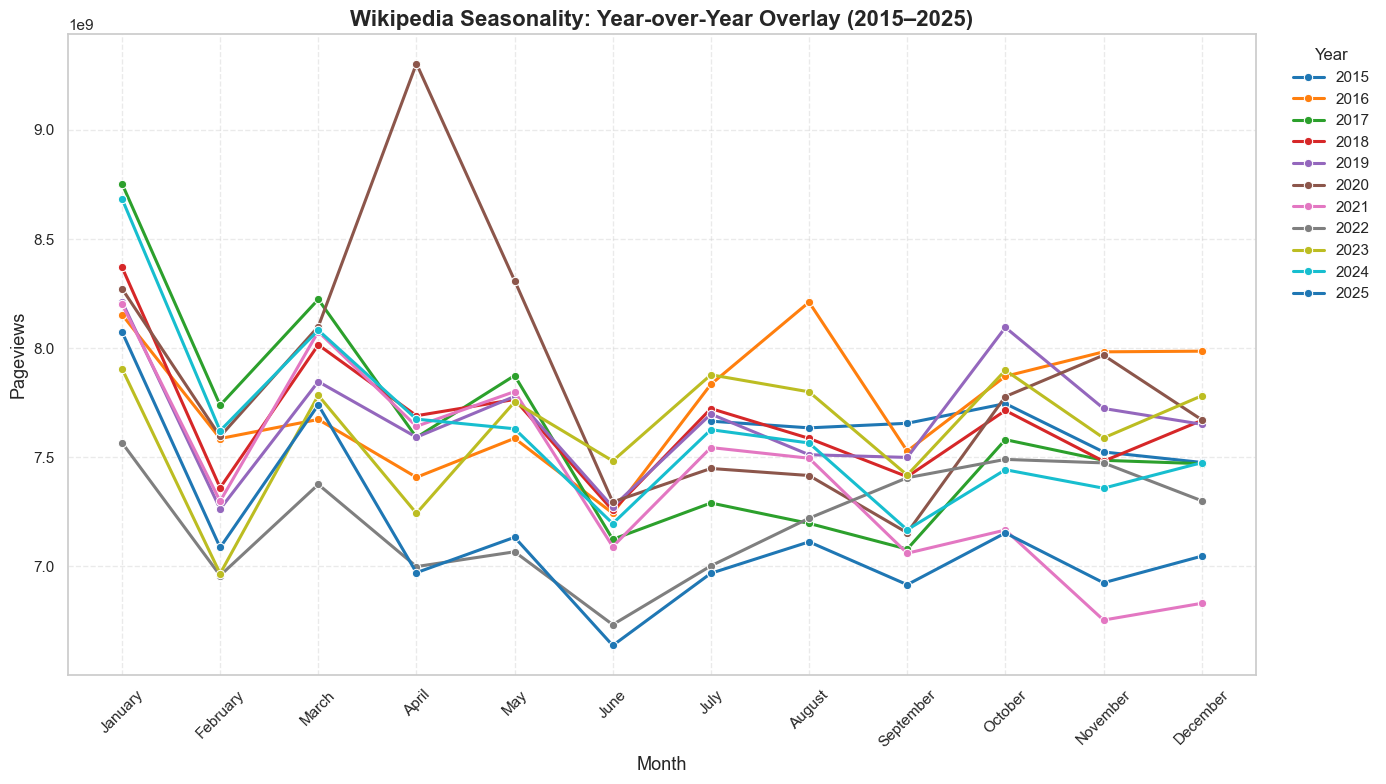

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
month_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
years = sorted(df['year'].unique())
palette = sns.color_palette("tab10", len(years))
plt.figure(figsize=(14,8))
sns.lineplot(
    data=df,x='month',y='views',hue='year',palette=palette,marker='o',linewidth=2.2
)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.title('Wikipedia Seasonality: Year-over-Year Overlay (2015–2025)', fontsize=16, weight='bold')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Pageviews', fontsize=13)

plt.legend(title='Year', bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'section_1_yoy_overlay.png'), dpi=300)
plt.show()

### Overview

The graph presents a year-over-year comparison of monthly Wikipedia pageviews from 2015 to 2025. By overlaying each year’s monthly data, the visualization makes it possible to identify recurring seasonal patterns and distinguish them from unusual deviations that occur in specific years.

### Seasonal Patterns
#### Mid-Year Dip Around June

A recurring pattern visible across many years is a decline in pageviews around June. Several years—including 2015, 2017, 2019, 2022, and 2025—show June as one of the lowest points within the year. Because this dip appears repeatedly across different years, it suggests a consistent seasonal slowdown in pageview activity.

#### Relatively Higher Values at the Start of the Year

Many years also show higher pageviews in January compared to the mid-year months. While the exact values vary between years, January often appears above June and nearby months, indicating relatively higher activity at the beginning of the year.

### Notable Yearly Outliers
#### April Spike in 2020

The most prominent anomaly in the dataset occurs in April 2020, where pageviews rise significantly above all other observations in the graph. This value stands well outside the range of typical monthly values.
The spike coincides with the early global spread of COVID-19, when use of online platforms increased dramatically. The magnitude of this increase makes it a clear outlier within the dataset.

#### August Peak in 2016

Another noticeable deviation occurs in **August 2016**, where pageviews rise to approximately **8.2 billion**, higher than most other years during that month and above the surrounding monthly values. While this increase is not as extreme as the spike observed in 2020, it still stands out within the dataset. Because the rise appears only in this specific year, it likely reflects a **temporary event-driven surge rather than a recurring seasonal pattern**. Although the dataset does not identify the exact cause, the period coincides with several widely followed global events, including the **Rio 2016 Olympic Games**, heightened attention during the **U.S. presidential election campaign**, and the viral popularity of **Pokémon GO**, all of which could have contributed to increased online information-seeking behavior.


#### Overall Pattern Across Years

Despite some isolated spikes, most monthly pageviews across the years fall within a relatively narrow band between roughly 7.0 and 8.0 billion pageviews. The general shape of the curves across different years remains broadly similar, indicating that Wikipedia usage follows a stable seasonal structure with occasional event-driven deviations.

